In [2]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties
from scipy.special import genlaguerre    #genlaguerre(n, alpha)
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import MultipleLocator

from matplotlib.lines import Line2D
import ipywidgets as widgets
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

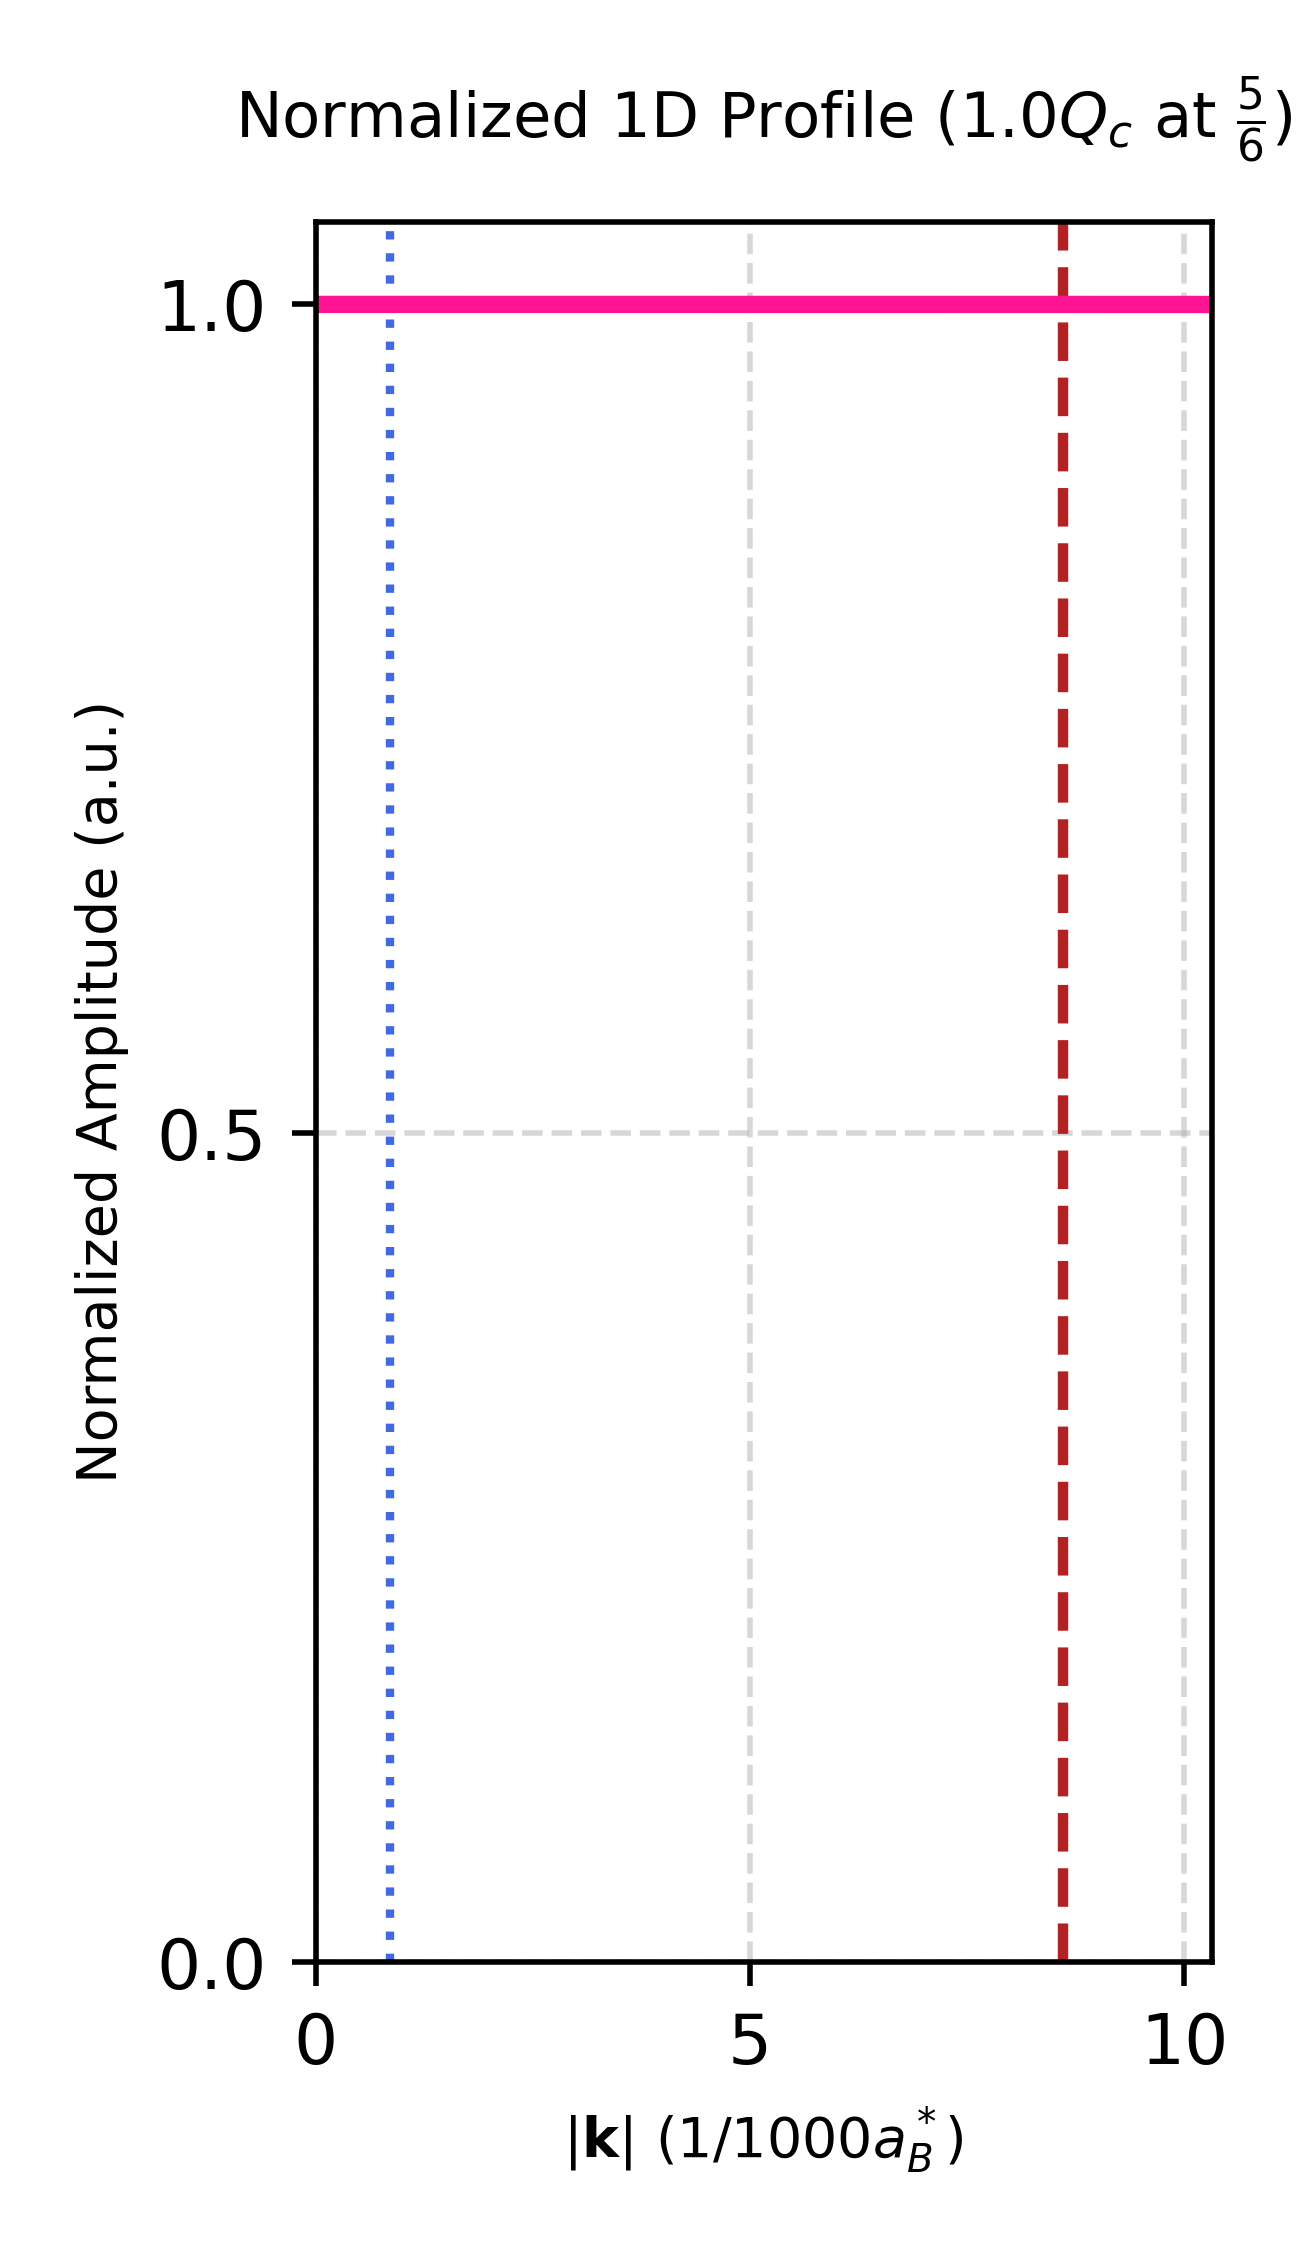

In [32]:
# =====================================================================
# CONFIGURATION: Choose your view mode here!
# Options: 
#   'zoomed'    -> Focuses tightly with 0.1 Q_c at 5/6 of the axis (xlim ~ 1.03)
#   'zoomed_1x' -> Focuses on the full 1.0 Q_c boundary at 5/6 of the axis (xlim ~ 10.32)
#   'full'      -> Extends the horizontal limit out to 3 / a_B^* (xlim = 3000)
# =====================================================================
VIEW_MODE = 'zoomed_1x'  # Toggle between 'zoomed', 'zoomed_1x', or 'full'
# VIEW_MODE = 'full'

# Define the function in terms of our scaled variable: k_scaled = k * (1000 * a_B)
def lambda_1s_scaled(k_scaled):
    denominator = (1 + (k_scaled / 2000)**2)**(1.5)
    return 1.0 / denominator

# Generate a wide range of k values to support all views smoothly
k_axis_vals = np.linspace(0, 6500, 2000)
lambda_vals_normalized = lambda_1s_scaled(k_axis_vals)

# Base lightcone values mapped to our 1/(1000 a_B^*) scale
k_01_qc = 0.86  # 0.1 Q_c
k_10_qc = 8.60  # 1.0 Q_c

# Default base figures dimensions
fig_width, fig_height = 6.5, 4.5
title_fs, label_fs, legend_fs = 12, 11, 10

# Initialize the plot layout container elements 
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=500)

# Dynamically set horizontal limits, plot styling, and lines based on selected mode
if VIEW_MODE == 'zoomed':
    x_max = k_01_qc * (6.0 / 5.0)  # 1.032
    plt.axvline(x=k_01_qc, color='royalblue', linestyle='--', linewidth=1.5, 
                label=r'$0.1 Q_c = 0.86\ \mu\mathrm{m}^{-1}$')
    legend_loc = 'lower left'
    title_suffix = r' (Zoomed to $0.1 Q_c$ at $\frac{5}{6}$)'
    
elif VIEW_MODE == 'zoomed_1x':
    x_max = k_10_qc * (6.0 / 5.0)  # 10.32
    
    # --- ADJUST FIGURE SIZE FOR THIS MODE ---
    # Shrink the horizontal size to 2/5 (40%) of the original width
    fig.set_size_inches(fig_width * 0.4, fig_height) # 2.6 inches x 4.5 inches
    
    # Scale down text elements proportionally so they don't overlap in a narrow frame
    title_fs, label_fs, legend_fs = 9, 8, 7
    
    # Show both the 1x boundary line at 5/6 and the 0.1x line close to 0 for scale context
    plt.axvline(x=k_10_qc, color='firebrick', linestyle='--', linewidth=1.5, 
                label=r'$1.0 Q_c = 8.6\ \mu\mathrm{m}^{-1}$')
    plt.axvline(x=k_01_qc, color='royalblue', linestyle=':', linewidth=1.2, 
                label=r'$0.1 Q_c$')
    legend_loc = 'lower left'
    title_suffix = r' ($1.0 Q_c$ at $\frac{5}{6}$)'
    
elif VIEW_MODE == 'full':
    x_max = 3.0 * 1000             # 3000
    plt.axvline(x=k_10_qc, color='firebrick', linestyle='--', linewidth=1.5, 
                label=r'$1.0 Q_c = 8.6\ \mu\mathrm{m}^{-1}$')
    legend_loc = 'upper right'
    title_suffix = r' (Full Decay to $3/a_B^*$)'
    
else:
    raise ValueError("VIEW_MODE must be 'zoomed', 'zoomed_1x', or 'full'")

# Plot the main function line
plt.plot(k_axis_vals, lambda_vals_normalized, color='deeppink', linewidth=2.5, 
         label=r'Normalized $\Lambda_{1s,\mathbf{0}}(vc\mathbf{k})$')

# Formatting Labels, Titles, and Limits using dynamic font sizes
plt.title(r'Normalized 1D Profile' + title_suffix, fontsize=title_fs, pad=12)
plt.xlabel(r'$|\mathbf{k}|$ ($1/1000a_B^*$)', fontsize=label_fs)
plt.ylabel('Normalized Amplitude (a.u.)', fontsize=label_fs)

plt.xlim(0, x_max) 
plt.ylim(0, 1.05)  
plt.grid(True, linestyle='--', alpha=0.5)
plt.yticks(np.arange(0, 1.1, 0.5))

# Optional: Uncomment if you want to see the legend inside the narrow column
# plt.legend(frameon=True, facecolor='white', edgecolor='none', loc=legend_loc, fontsize=legend_fs)

plt.tight_layout()
plt.savefig(f'normalized_profile_{VIEW_MODE}.png')
plt.show()

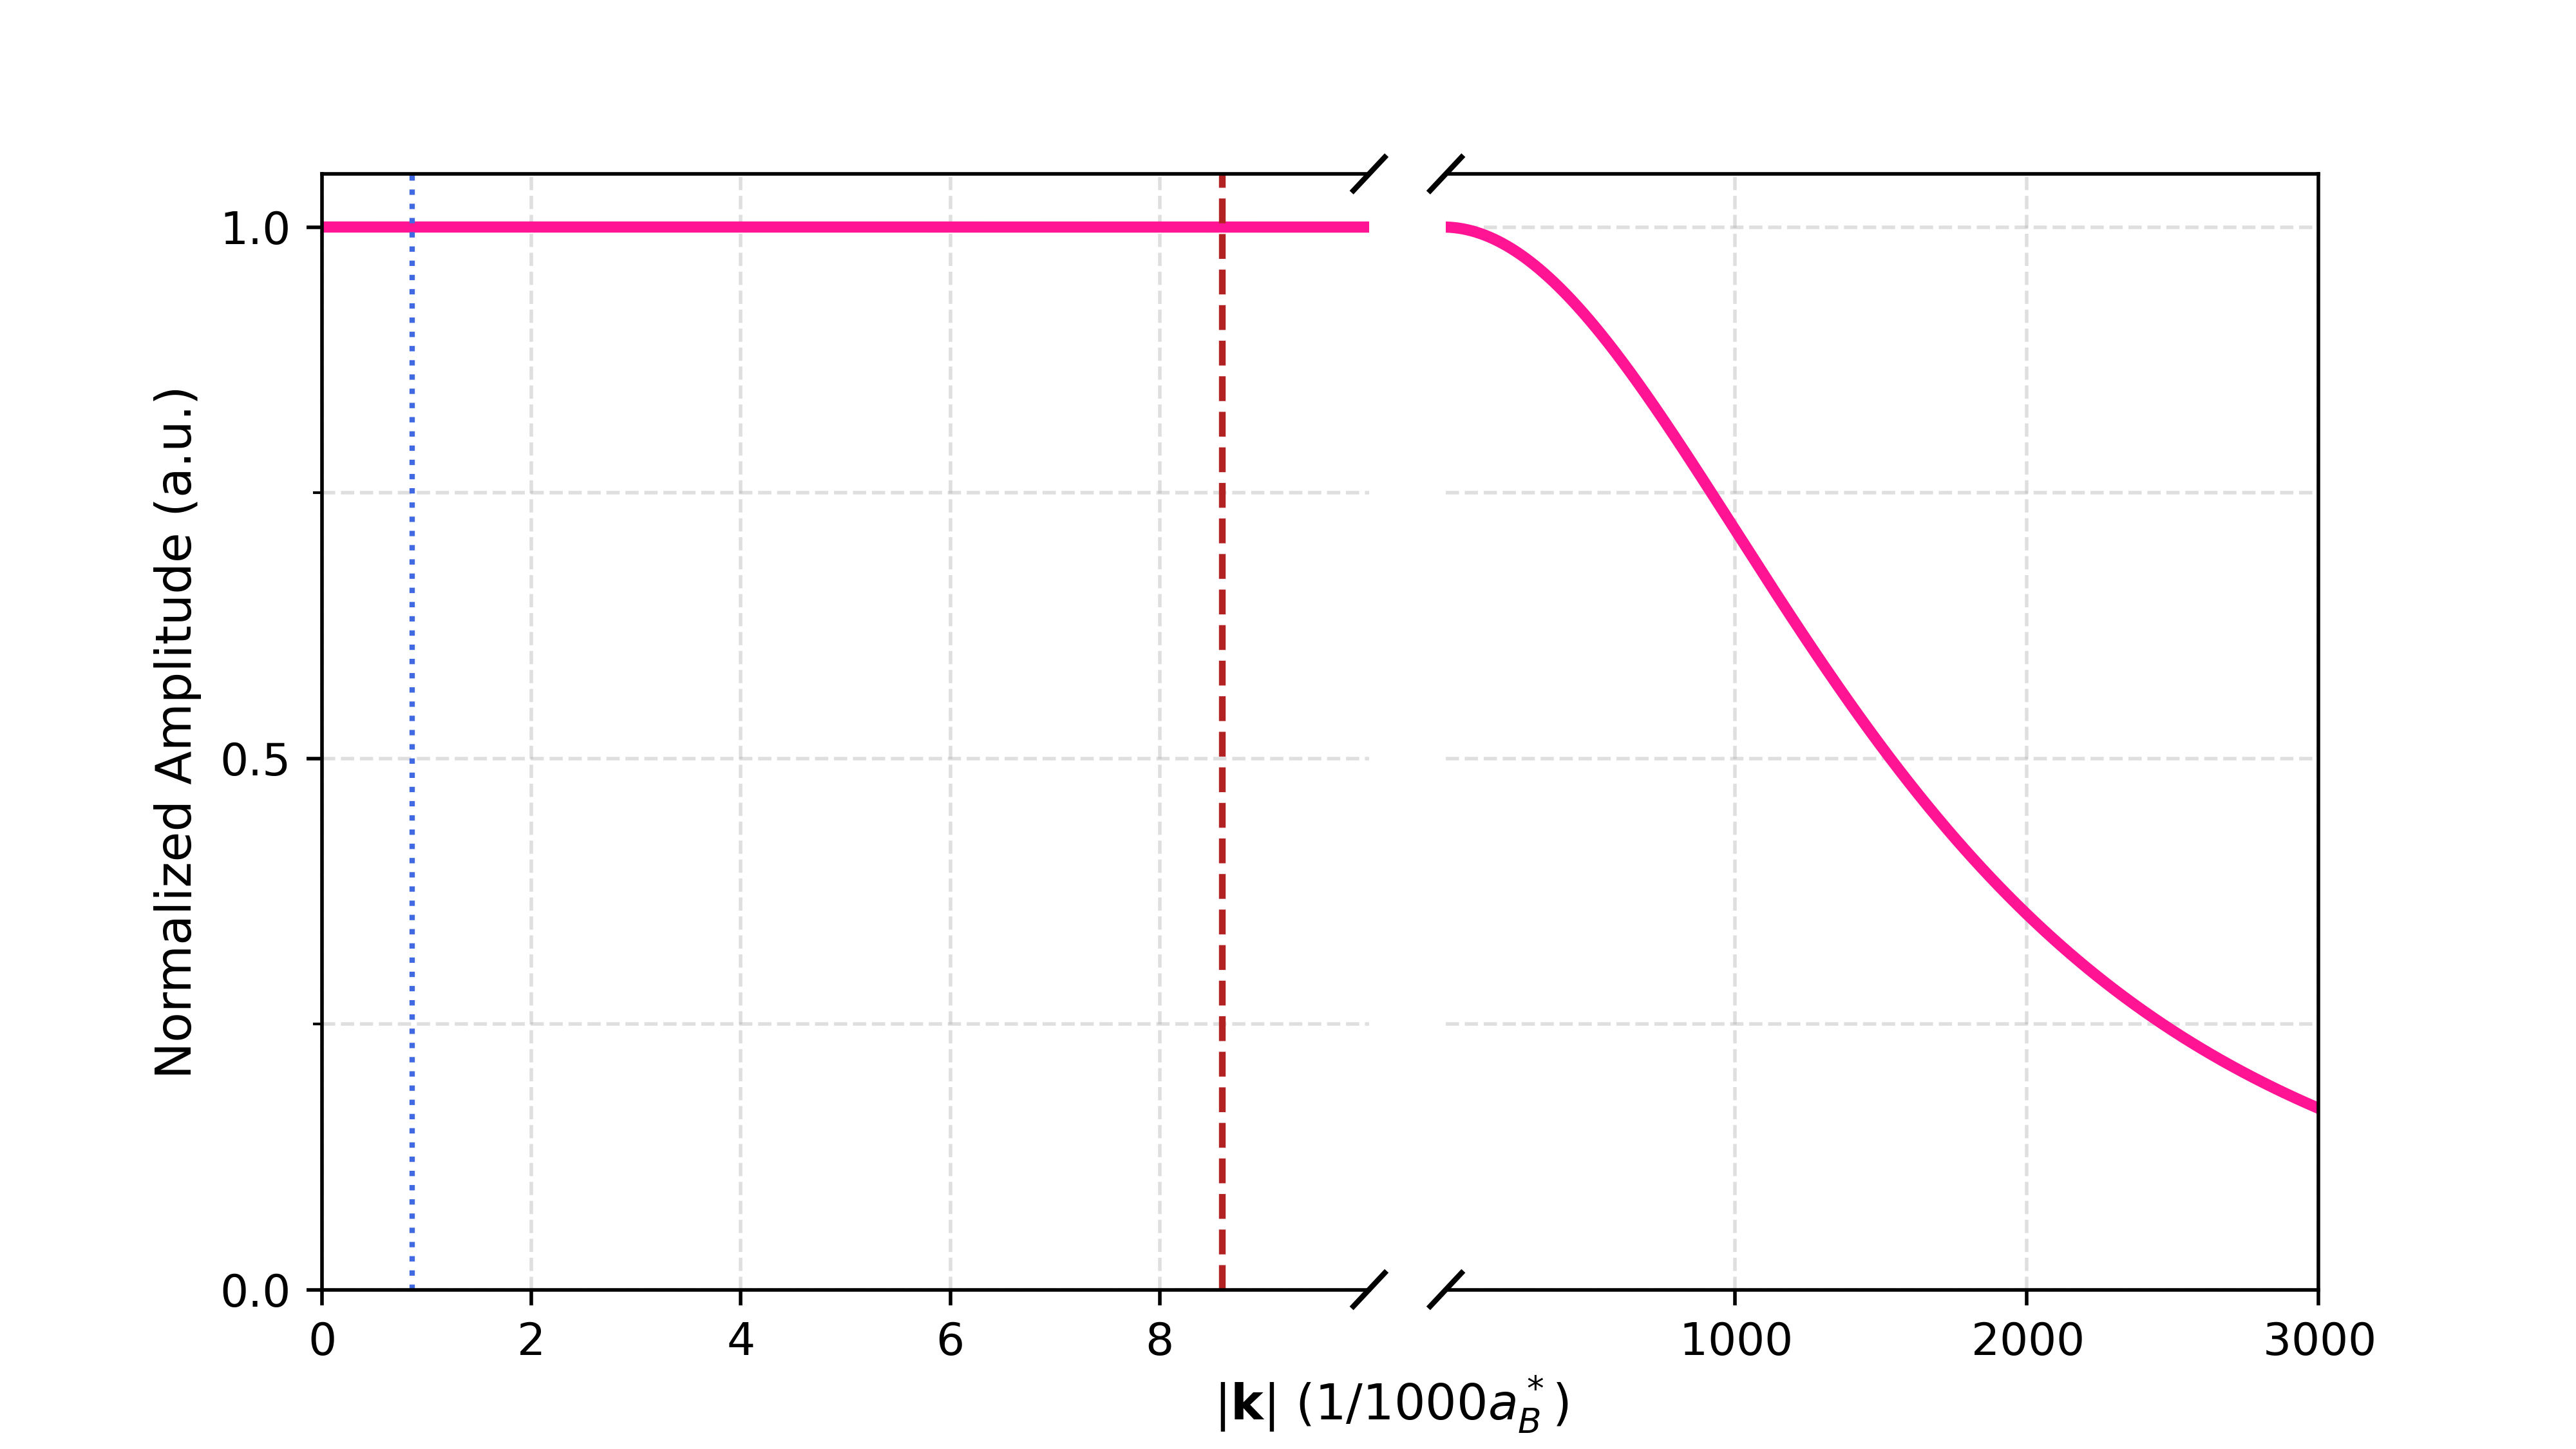

In [49]:
# Define the function in terms of our scaled variable: k_scaled = k * (1000 * a_B)
def lambda_1s_scaled(k_scaled):
    denominator = (1 + (k_scaled / 2000)**2)**(1.5)
    return 1.0 / denominator

# Base lightcone values mapped to our 1/(1000 a_B^*) scale
k_01_qc = 0.86  # 0.1 Q_c
k_10_qc = 8.60  # 1.0 Q_c

# Create a figure with two side-by-side subplots sharing the same Y axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4.5), dpi=500,
                               gridspec_kw={'width_ratios': [1.2, 1]})

# Adjust layout space between subplots to make space for the break mark
plt.subplots_adjust(wspace=0.08)

# --- Left Plot (Zoomed Lightcone Region) ---
k_left = np.linspace(0, 12, 500)
ax1.plot(k_left, lambda_1s_scaled(k_left), color='deeppink', linewidth=2.5)
ax1.axvline(x=k_10_qc, color='firebrick', linestyle='--', linewidth=1.5, 
            label=r'$1.0 Q_c = 8.6\ \mu\mathrm{m}^{-1}$')
ax1.axvline(x=k_01_qc, color='royalblue', linestyle=':', linewidth=1.2, 
            label=r'$0.1 Q_c = 0.86\ \mu\mathrm{m}^{-1}$')

ax1.set_xlim(0, 10) # Places 1.0 Q_c exactly at 5/6 of this left axis
ax1.set_xticks([0, 2, 4, 6, 8])
ax1.set_ylabel('Normalized Amplitude (a.u.)', fontsize=11)

# --- Right Plot (Full Decay Region) ---
k_right = np.linspace(10, 3000, 1000)
ax2.plot(k_right, lambda_1s_scaled(k_right), color='deeppink', linewidth=2.5)

ax2.set_xlim(10, 3000)
ax2.set_xticks([1000, 2000, 3000])
ax2.set_xticklabels([r'$1000$', r'$2000$', r'$3000$'])

# --- Styling & Broken Axis Line Treatment ---
for ax in [ax1, ax2]:
    ax.set_ylim(0, 1.05)
    
    # 1. Major Y-ticks: These will show labels at 0, 0.5, 1.0
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}' if y in [0.0, 0.5, 1.0] else ''))
    
    # 2. Minor Y-ticks: Placed at 0.25 and 0.75 without text labels
    ax.set_yticks([0.25, 0.75], minor=True)
    
    # 3. Enable grid on BOTH 'major' and 'minor' tick levels
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

# Remove internal spine borders to make them look like a singular layout
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Remove ALL tick lines (both major and minor) from the right-hand plot's vertical axis
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# Create the broken axis diagonal marks ("//")
d = .015  # Size of the break marks
kwargs = dict(transform=ax1.transAxes, color='black', clip_on=False, linewidth=1.2)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)        # Top-right mark
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right mark

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 1.2, +d * 1.2), (-d, +d), **kwargs)        # Top-left mark
ax2.plot((-d * 1.2, +d * 1.2), (1 - d, 1 + d), **kwargs)  # Bottom-left mark

# Singular centered figure label spanning across both panels
fig.text(0.54, 0.02, r'$|\mathbf{k}|$ ($1/1000a_B^*$)', ha='center', fontsize=11)

plt.savefig('combined_broken_axis_profile.png', bbox_inches='tight')
plt.show()